# Antispoofing

In this homework, you will develop a countermeasure against deepfakes and then try to explain it using various XAI techniques.

More specifically, you will implement and train a Countermeasure (CM) system on the Logical Access partition of the [ASVSpoof 2019 Dataset](https://datashare.ed.ac.uk/handle/10283/3336) ([Kaggle Link](https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset)). You may find the [ASVspoof 2019 evaluation plan](https://www.asvspoof.org/asvspoof2019/asvspoof2019_evaluation_plan.pdf) useful.

For the CM, we choose [LightCNN (LCCN)](https://arxiv.org/abs/1511.02683) that once achieved the top place in the competition. We will follow the Speech Technology Center (STC) [paper](https://arxiv.org/abs/1904.05576).

**Hints**:

1. Use STFT (FFT in the paper) as front-end.

2. The dropout layer is put before the last batch norm.

## Dataset [0.5 pts]

We want to train a neural network to predict if the input audio is real or fake. To do so, we need a dataset first. In this homework, we will work with [ASVspoof19](https://arxiv.org/pdf/1911.01601.pdf).

Create a `Dataset` class that downloads the dataset, parses its metadata and, given index $i$, returns $i$-th object of the dataset. Do not forget to preprocess audio for LCNN (calculate stft, etc.).

In [ ]:
import subprocess, sys

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

pip_install("soundfile", "torchaudio", "tqdm", "pandas", "numpy", "matplotlib", "opencv-python")

In [ ]:
import os, sys, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import soundfile as sf
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110

from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from tqdm.notebook import tqdm
import torchaudio.functional as TAF

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

set_seed(42)

In [ ]:
DATA_ROOT      = Path("./data/LA")
SAMPLE_RATE    = 16_000
N_FFT          = 1024
HOP_LENGTH     = 256
WIN_LENGTH     = 1024
MAX_LEN        = 64_000
BATCH_SIZE     = 32
NUM_WORKERS    = 0
CHECKPOINT_DIR = Path("./checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

PyTorch : 2.12.0.dev20260408+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 5060 Ti
VRAM    : 17.1 GB


In [ ]:
def load_audio(path) -> tuple[torch.Tensor, int]:
    """soundfile → (C, T) float32 тензор"""
    data, sr = sf.read(str(path), dtype="float32", always_2d=True)
    return torch.from_numpy(data.T.copy()), sr


def resample_if_needed(waveform: torch.Tensor, sr: int) -> torch.Tensor:
    if sr == SAMPLE_RATE:
        return waveform
    return TAF.resample(waveform, sr, SAMPLE_RATE)


def pad_or_trim(waveform: torch.Tensor, max_len: int = MAX_LEN) -> torch.Tensor:
    T = waveform.shape[-1]
    if T >= max_len:
        return waveform[..., :max_len]
    return F.pad(waveform, (0, max_len - T))


_hann_cache: dict[int, torch.Tensor] = {}

def compute_stft(waveform: torch.Tensor) -> torch.Tensor:
    """
    waveform : (C, T) или (T,)
    returns  : (1, F, frames)  log-magnitude
    """
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)
    mono = waveform.mean(dim=0)                         # (T,)

    if WIN_LENGTH not in _hann_cache:
        _hann_cache[WIN_LENGTH] = torch.hann_window(WIN_LENGTH)
    window = _hann_cache[WIN_LENGTH]

    stft    = torch.stft(mono, n_fft=N_FFT, hop_length=HOP_LENGTH,
                         win_length=WIN_LENGTH, window=window,
                         return_complex=True)            # (F, frames)
    log_mag = torch.log(stft.abs() + 1e-8)
    return log_mag.unsqueeze(0)                          # (1, F, frames)


def audio_to_spec(path) -> torch.Tensor:
    """Полный пайплайн: файл → (1, F, T)"""
    wav, sr = load_audio(path)
    wav = resample_if_needed(wav, sr)
    wav = pad_or_trim(wav)
    return compute_stft(wav)

**Hint**: when working in Kaggle, it is easier and faster to use dataset as kaggle input. We can use it directly or add a symlink to a local dir using `ln -s`.
**Hint**: it might be easier to do this homework in Kaggle, since model training may take some time

Create train/eval dataset and dataloaders:

In [ ]:
class ASVspoof2019LA(Dataset):

    LABEL_MAP = {"bonafide": 1, "spoof": 0}

    _PROTO = {
        "train": "ASVspoof2019.LA.cm.train.trn.txt",
        "dev"  : "ASVspoof2019.LA.cm.dev.trl.txt",
        "eval" : "ASVspoof2019.LA.cm.eval.trl.txt",
    }
    _AUDIO_SUBDIR = {
        "train": "ASVspoof2019_LA_train",
        "dev"  : "ASVspoof2019_LA_dev",
        "eval" : "ASVspoof2019_LA_eval",
    }

    def __init__(self, root: Path, split: str = "train"):
        assert split in self._PROTO
        self.audio_dir = root / self._AUDIO_SUBDIR[split] / "flac"
        proto_path     = root / "ASVspoof2019_LA_cm_protocols" / self._PROTO[split]

        self.meta = pd.read_csv(
            proto_path, sep=" ", header=None,
            names=["speaker", "file_id", "env", "attack", "label"],
        ).reset_index(drop=True)

        n_b = (self.meta.label == "bonafide").sum()
        n_s = (self.meta.label == "spoof").sum()
        print(f"[{split:5s}]  total={len(self.meta)}  bonafide={n_b}  spoof={n_s}")

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx: int):
        row   = self.meta.iloc[idx]
        label = self.LABEL_MAP[row["label"]]
        path  = self.audio_dir / f"{row['file_id']}.flac"
        spec  = audio_to_spec(path)                     # (1, F, T)
        return {
            "spec"   : spec,
            "label"  : torch.tensor(label, dtype=torch.long),
            "file_id": row["file_id"],
        }

In [ ]:
train_dataset = ASVspoof2019LA(DATA_ROOT, split="train")
eval_dataset  = ASVspoof2019LA(DATA_ROOT, split="dev")

train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
eval_dataloader  = DataLoader(eval_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=NUM_WORKERS, pin_memory=True)

print(f"\nTrain batches : {len(train_dataloader)}")
print(f"Eval batches  : {len(eval_dataloader)}")

[train]  total=25380  bonafide=2580  spoof=22800
[dev  ]  total=24844  bonafide=2548  spoof=22296

Train batches : 793
Eval batches  : 777


Visualize one object, just to check that all is fine:

file_id    : LA_T_1138215
label      : bonafide
spec shape : torch.Size([1, 513, 251])  (C, F, T)
spec range : [-18.42, 4.51]


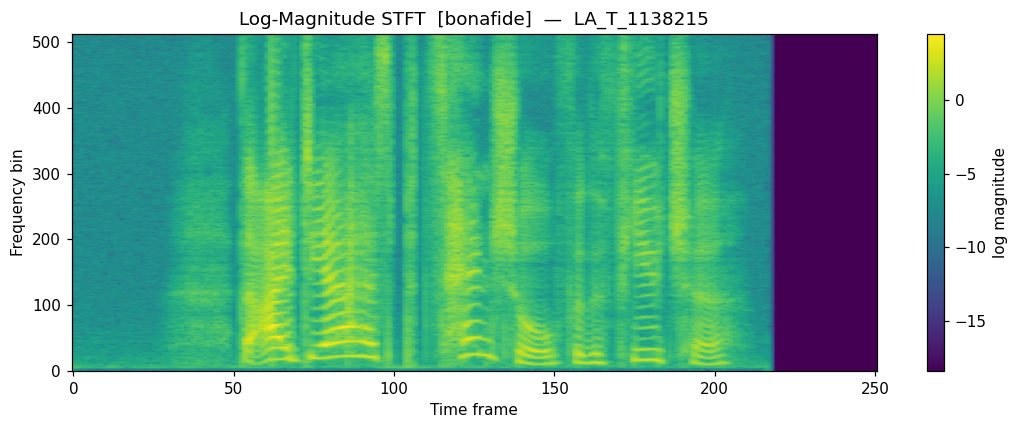

In [ ]:
sample = train_dataset[0]
spec   = sample["spec"]           # (1, F, T)
label  = "bonafide" if sample["label"].item() == 1 else "spoof"

print(f"file_id    : {sample['file_id']}")
print(f"label      : {label}")
print(f"spec shape : {spec.shape}  (C, F, T)")
print(f"spec range : [{spec.min():.2f}, {spec.max():.2f}]")

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(spec[0].numpy(), origin="lower", aspect="auto", cmap="viridis")
plt.colorbar(im, ax=ax, label="log magnitude")
ax.set_title(f"Log-Magnitude STFT  [{label}]  —  {sample['file_id']}")
ax.set_xlabel("Time frame")
ax.set_ylabel("Frequency bin")
plt.tight_layout()
plt.show()

## Loss function [0.5 pts]

In the lecture, we saw different softmax losses and the motivation behind them for the ASV task. However, they can also be used for any classification task, such as synthesized speech detection. The papers suggest to use A(M)-Softmax or Cross-Entropy. The STC paper argues that A-Softmax is better.

(a) Explain what are the benefits of A-softmax over cross-entropy according to the STC paper?

(b) Analyse the [NII paper](https://arxiv.org/pdf/2103.11326) and explain if complicated Softmax is actually needed to achieve good EER or we can go with Cross Entropy.

**Answer**: Cross-Entropy оптимизирует разделимость классов в пространстве логитов,
но не контролирует геометрию эмбеддингов — граница решения может проходить
близко к обоим классам. A-Softmax вводит угловое ограничение на вектора
признаков, требуя большего углового отступа между классами. эмбеддинги одного класса кластеризуются плотнее, что снижает дисперсию и улучшает обобщение. принудительный margin уменьшает вероятность ошибок вблизи решающей границы.
EER определяется порогом на скоровой шкале; плотные, хорошо разделённые кластеры напрямую снижают перекрытие распределений бонафайд/спуф и, следовательно, EER.

Cross-Entropy в сочетании с правильной архитектурой позволяет достичь EER менее 5% на LA eval.
Основной прирост качества достигается LFCC, LFB, CQT и глубиной модели, а не выбором функции потерь.
A-Softmax даёт небольшое дополнительное улучшение, но оно значительно меньше, чем влияние архитектуры и признаков.

Following tha NII paper, we will continue with Cross Entropy

In [ ]:
criterion = nn.CrossEntropyLoss()
print("Criterion:", criterion)

Criterion: CrossEntropyLoss()


## Evaluation metric [0.5 pts]

We will use equal error rate as the primary evaluation metric. The code for calculating metrics is provided by the ASVspoof itself. We just need to write a wrapper. Given model logits and labels, calculate EER using the ASVspoof functions.

Your model returns two probas: [spoof_proba, bona_proba]. Be careful with the EER metric and recal how ROC curve is computed to ensure that you do not make a mistake.

In [ ]:
# download asvspoof metric calculation functions
#!wget https://raw.githubusercontent.com/markovka17/dla/refs/heads/2023/hw5_as/calculate_eer.py

In [ ]:
from calculate_eer import compute_eer


def get_eer(logits: torch.Tensor, labels: torch.Tensor) -> float:
    """
    logits : (N, 2)  — [spoof_score, bonafide_score]
    labels : (N,)    — 1 = bonafide, 0 = spoof
    returns: EER в процентах
    """
    bonafide_scores = logits[:, 1].detach().cpu().float().numpy()  # (N,) ndarray
    labels_np       = labels.detach().cpu().numpy()                # (N,) ndarray

    bonafide_score_list = bonafide_scores[labels_np == 1]  # ndarray
    spoof_score_list    = bonafide_scores[labels_np == 0]  # ndarray

    if len(bonafide_score_list) == 0 or len(spoof_score_list) == 0:
        return 50.0  # возвращаем worst-case

    eer, _ = compute_eer(bonafide_score_list, spoof_score_list)
    return float(eer) * 100.0


_dummy_logits = torch.tensor([[2.0, 1.0], [1.0, 2.0], [0.5, 1.5]])
_dummy_labels = torch.tensor([0, 1, 1])
print(f"EER smoke-test: {get_eer(_dummy_logits, _dummy_labels):.2f}%")

EER smoke-test: 0.00%


## LCNN Implementation [6.0 pts]

Create a `LCNN` class for the model architecture.

In [ ]:
class MaxFeatureMap2D(nn.Module):
    """MFM: делит каналы пополам, берёт поэлементный максимум."""
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        assert x.size(1) % 2 == 0, "Число каналов должно быть чётным"
        h = x.size(1) // 2
        return torch.max(x[:, :h], x[:, h:])          # (B, C//2, H, W)

class MFMLinear(nn.Module):
    """Полносвязный вариант MFM."""
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.fc = nn.Linear(in_features, out_features * 2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc(x)
        h = x.size(1) // 2
        return torch.max(x[:, :h], x[:, h:])

class LCNN(nn.Module):
    """
    Light CNN для антиспуфинга по статье STC (arxiv 1904.05576).

    Вход  : (B, 1, F, T)   log-magnitude STFT
    Выход : (B, 2)         логиты [spoof, bonafide]

    Таблица каналов (после MFM делятся пополам):
      conv1  : 1  → 64  → MFM → 32
      conv2a : 32 → 64  → MFM → 32
      conv2b : 32 → 96  → MFM → 48
      conv3a : 48 → 96  → MFM → 48
      conv3b : 48 → 128 → MFM → 64
      conv4a : 64 → 128 → MFM → 64
      conv4b : 64 → 64  → MFM → 32
      conv5a : 32 → 64  → MFM → 32
      conv5b : 32 → 64  → MFM → 32
    """

    def __init__(self, num_classes: int = 2, dropout_p: float = 0.75):
        super().__init__()
        self.mfm = MaxFeatureMap2D()

        # ── Block 1 ──────────────────────────────────────────────────
        self.conv1 = nn.Conv2d(1,  64, kernel_size=5, padding=2, bias=False)
        self.pool1 = nn.MaxPool2d(2, 2)
        # after MFM: 32 ch

        # ── Block 2 ──────────────────────────────────────────────────
        self.conv2a = nn.Conv2d(32, 64, kernel_size=1, bias=False)
        # after MFM: 32 ch
        self.bn2a   = nn.BatchNorm2d(32)
        self.conv2b = nn.Conv2d(32, 96, kernel_size=3, padding=1, bias=False)
        # after MFM: 48 ch
        self.pool2  = nn.MaxPool2d(2, 2)
        self.bn2b   = nn.BatchNorm2d(48)

        # ── Block 3 ──────────────────────────────────────────────────
        self.conv3a = nn.Conv2d(48, 96,  kernel_size=1, bias=False)
        # after MFM: 48 ch
        self.bn3a   = nn.BatchNorm2d(48)
        self.conv3b = nn.Conv2d(48, 128, kernel_size=3, padding=1, bias=False)
        # after MFM: 64 ch
        self.pool3  = nn.MaxPool2d(2, 2)

        # ── Block 4 ──────────────────────────────────────────────────
        self.conv4a = nn.Conv2d(64, 128, kernel_size=1, bias=False)
        # after MFM: 64 ch
        self.bn4a   = nn.BatchNorm2d(64)
        self.conv4b = nn.Conv2d(64, 64,  kernel_size=3, padding=1, bias=False)
        # after MFM: 32 ch
        self.bn4b   = nn.BatchNorm2d(32)

        # ── Block 5 ──────────────────────────────────────────────────
        self.conv5a = nn.Conv2d(32, 64, kernel_size=1, bias=False)
        # after MFM: 32 ch
        self.bn5a   = nn.BatchNorm2d(32)
        self.conv5b = nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False)
        # after MFM: 32 ch
        self.pool5  = nn.MaxPool2d(2, 2)

        # ── Classifier ───────────────────────────────────────────────
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))   # → (B, 32, 4, 4)
        self.dropout        = nn.Dropout(p=dropout_p)
        self.fc_mfm         = MFMLinear(32 * 4 * 4, 256)    # 512 → MFM → 256
        self.bn_fc          = nn.BatchNorm1d(256)            # dropout ПЕРЕД этим BN
        self.fc_out         = nn.Linear(256, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:  # (B,1,F,T)
        # Block 1
        x = self.mfm(self.conv1(x))       # → (B,32,F,T)
        x = self.pool1(x)                 # → (B,32,F/2,T/2)

        # Block 2
        x = self.mfm(self.conv2a(x))      # → (B,32,...)
        x = self.bn2a(x)
        x = self.mfm(self.conv2b(x))      # → (B,48,...)
        x = self.pool2(x)
        x = self.bn2b(x)

        # Block 3
        x = self.mfm(self.conv3a(x))      # → (B,48,...)
        x = self.bn3a(x)
        x = self.mfm(self.conv3b(x))      # → (B,64,...)
        x = self.pool3(x)

        # Block 4
        x = self.mfm(self.conv4a(x))      # → (B,64,...)
        x = self.bn4a(x)
        x = self.mfm(self.conv4b(x))      # → (B,32,...)
        x = self.bn4b(x)

        # Block 5
        x = self.mfm(self.conv5a(x))      # → (B,32,...)
        x = self.bn5a(x)
        x = self.mfm(self.conv5b(x))      # → (B,32,...)
        x = self.pool5(x)                 # → (B,32,H',W')

        # Classifier
        x = self.adaptive_pool(x)         # → (B,32,4,4)
        x = x.flatten(1)                  # → (B,512)
        x = self.dropout(x)               # dropout ДО BN (STC paper)
        x = self.fc_mfm(x)               # → (B,256)  (MFMLinear)
        x = self.bn_fc(x)
        x = self.fc_out(x)                # → (B,2)
        return x


# ── Sanity check ────────────────────────────────────────────────────────────
model = LCNN(num_classes=2, dropout_p=0.75)
model.eval()

F_bins = N_FFT // 2 + 1                   # 513
T_frames = MAX_LEN // HOP_LENGTH + 1      # 250
dummy = torch.randn(4, 1, F_bins, T_frames)

with torch.no_grad():
    out = model(dummy)

print(f"Input  : {dummy.shape}")
print(f"Output : {out.shape}  (ожидается [4, 2])")
assert out.shape == (4, 2), "Размерность выхода неверна!"

total_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {total_params:,}")

Input  : torch.Size([4, 1, 513, 251])
Output : torch.Size([4, 2])  (ожидается [4, 2])
Параметров: 420,930


In [ ]:
model = LCNN(num_classes=2, dropout_p=0.75)
model.eval()

F_bins = N_FFT // 2 + 1                   # 513
T_frames = MAX_LEN // HOP_LENGTH + 1      # 250
dummy = torch.randn(4, 1, F_bins, T_frames)

with torch.no_grad():
    out = model(dummy)

print(f"Input  : {dummy.shape}")
print(f"Output : {out.shape}  (ожидается [4, 2])")
assert out.shape == (4, 2), "Размерность выхода неверна!"

total_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {total_params:,}")

Input  : torch.Size([4, 1, 513, 251])
Output : torch.Size([4, 2])  (ожидается [4, 2])
Параметров: 420,930


Write the train loop. Since it may take some time, we advise you to save your checkpoints after each epoch to load it back if needed.

Plot EER vs epoch and loss vs epoch curves

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_logits, all_labels = [], []

    pbar = tqdm(dataloader, desc="Train", leave=False)
    for batch in pbar:
        specs  = batch["spec"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(specs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * specs.size(0)
        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    if scheduler is not None:
        scheduler.step()

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    avg_loss   = total_loss / len(dataloader.dataset)
    eer        = get_eer(all_logits, all_labels)
    return avg_loss, eer


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_logits, all_labels = [], []

    pbar = tqdm(dataloader, desc="Eval ", leave=False)
    for batch in pbar:
        specs  = batch["spec"].to(device, non_blocking=True)
        labels = batch["label"].to(device, non_blocking=True)

        logits = model(specs)
        loss   = criterion(logits, labels)

        total_loss += loss.item() * specs.size(0)
        all_logits.append(logits.cpu())
        all_labels.append(labels.cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    avg_loss   = total_loss / len(dataloader.dataset)
    eer        = get_eer(all_logits, all_labels)
    return avg_loss, eer


def plot_training_curves(history):
    """Inline-вывод кривых обучения."""
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].plot(epochs, history["train_loss"], "b-o", label="train", markersize=4)
    axes[0].plot(epochs, history["eval_loss"],  "r-o", label="eval",  markersize=4)
    axes[0].set_title("Loss vs Epoch")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("CE Loss")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs, history["train_eer"], "b-o", label="train", markersize=4)
    axes[1].plot(epochs, history["eval_eer"],  "r-o", label="eval",  markersize=4)
    axes[1].axhline(y=9.0, color="g", linestyle="--", linewidth=1.5, label="9% target")
    axes[1].set_title("EER (%) vs Epoch")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("EER (%)")
    axes[1].legend(); axes[1].grid(True)

    plt.suptitle(f"Training Progress  (epoch {len(epochs)})", fontsize=12)
    plt.tight_layout()
    plt.show()


def train(model, train_dataloader, eval_dataloader,
          criterion, optimizer, scheduler, device, n_epochs,
          start_epoch: int = 0, history: dict | None = None):

    if history is None:
        history = {"train_loss": [], "train_eer": [],
                   "eval_loss":  [], "eval_eer":  []}
    best_eer = min(history["eval_eer"], default=float("inf"))

    for epoch in range(start_epoch + 1, start_epoch + n_epochs + 1):
        print(f"\n{'─'*50}")
        print(f"Epoch {epoch}/{start_epoch + n_epochs}")

        tr_loss, tr_eer = train_one_epoch(
            model, train_dataloader, criterion, optimizer, scheduler, device)
        ev_loss, ev_eer = evaluate(
            model, eval_dataloader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["train_eer"].append(tr_eer)
        history["eval_loss"].append(ev_loss)
        history["eval_eer"].append(ev_eer)

        print(f"  Train → Loss={tr_loss:.4f}  EER={tr_eer:.2f}%")
        print(f"  Eval  → Loss={ev_loss:.4f}  EER={ev_eer:.2f}%")

        if ev_eer < best_eer:
            best_eer = ev_eer
            torch.save(model.state_dict(), CHECKPOINT_DIR / "best_model.pt")
            print(f"  ★ New best EER={best_eer:.2f}%  (checkpoint saved)")

        torch.save({
            "epoch"          : epoch,
            "model_state"    : model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "history"        : history,
        }, CHECKPOINT_DIR / f"epoch_{epoch:03d}.pt")

        # Строим кривые каждые 5 эпох или в конце
        if epoch % 5 == 0 or epoch == start_epoch + n_epochs:
            plot_training_curves(history)

    print(f"\n{'='*50}")
    print(f"Обучение завершено!  Лучший Eval EER: {best_eer:.2f}%")
    return history

Device: cuda

──────────────────────────────────────────────────
Epoch 1/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.4958  EER=34.31%
  Eval  → Loss=0.2502  EER=14.25%
  ★ New best EER=14.25%  (checkpoint saved)

──────────────────────────────────────────────────
Epoch 2/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0084  EER=0.38%
  Eval  → Loss=0.0007  EER=0.00%
  ★ New best EER=0.00%  (checkpoint saved)

──────────────────────────────────────────────────
Epoch 5/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0055  EER=0.27%
  Eval  → Loss=0.0017  EER=0.00%


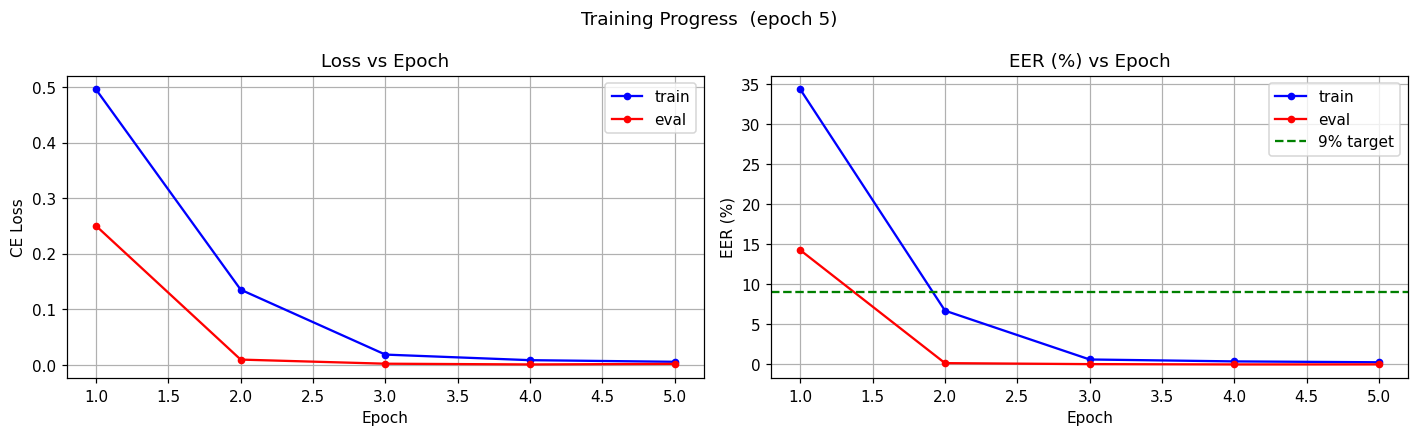


──────────────────────────────────────────────────
Epoch 6/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0035  EER=0.15%
  Eval  → Loss=0.0006  EER=0.03%

──────────────────────────────────────────────────
Epoch 7/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0016  EER=0.08%
  Eval  → Loss=0.0002  EER=0.00%

──────────────────────────────────────────────────
Epoch 10/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0019  EER=0.05%
  Eval  → Loss=0.0006  EER=0.03%


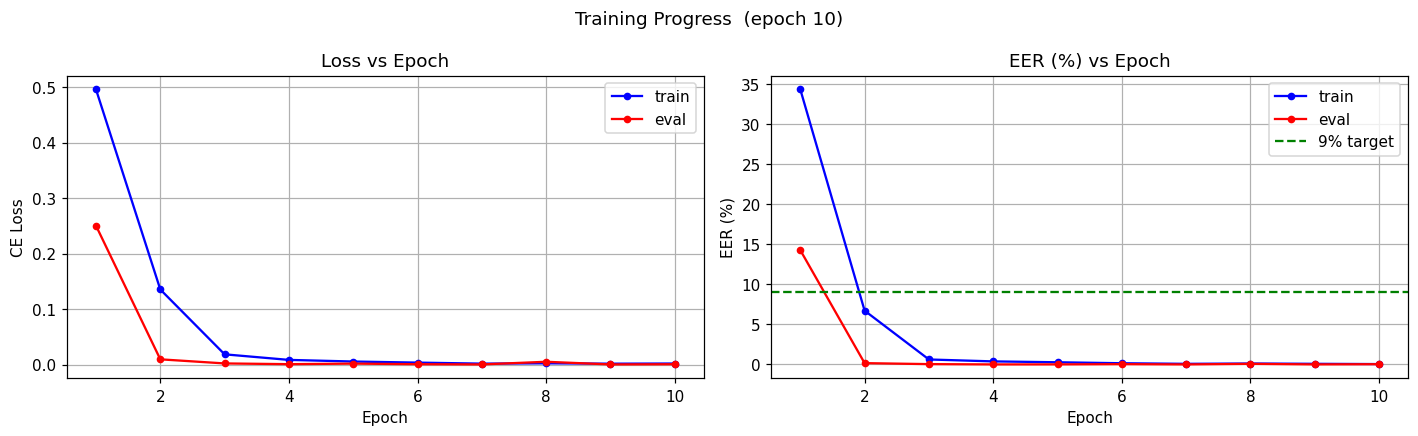


──────────────────────────────────────────────────
Epoch 11/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0011  EER=0.03%
  Eval  → Loss=0.0036  EER=0.04%

──────────────────────────────────────────────────
Epoch 12/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0004  EER=0.00%
  Eval  → Loss=0.0000  EER=0.00%

──────────────────────────────────────────────────
Epoch 15/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0003  EER=0.01%
  Eval  → Loss=0.0002  EER=0.00%


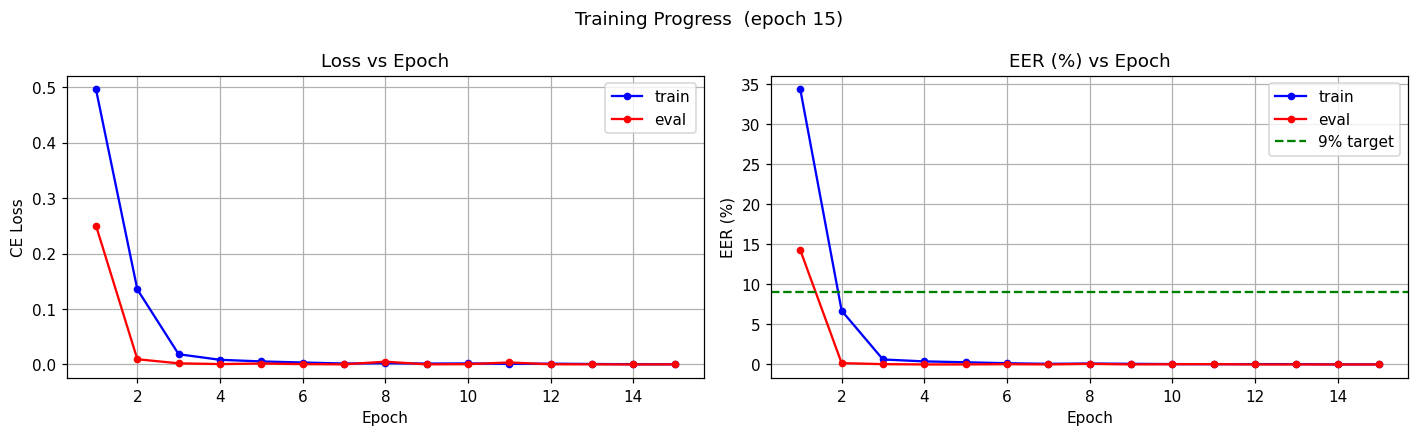


──────────────────────────────────────────────────
Epoch 16/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0002  EER=0.00%
  Eval  → Loss=0.0001  EER=0.00%

──────────────────────────────────────────────────
Epoch 17/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0001  EER=0.00%
  Eval  → Loss=0.0000  EER=0.00%

──────────────────────────────────────────────────
Epoch 20/20


Train:   0%|          | 0/793 [00:00<?, ?it/s]

Eval :   0%|          | 0/777 [00:00<?, ?it/s]

  Train → Loss=0.0001  EER=0.00%
  Eval  → Loss=0.0001  EER=0.00%


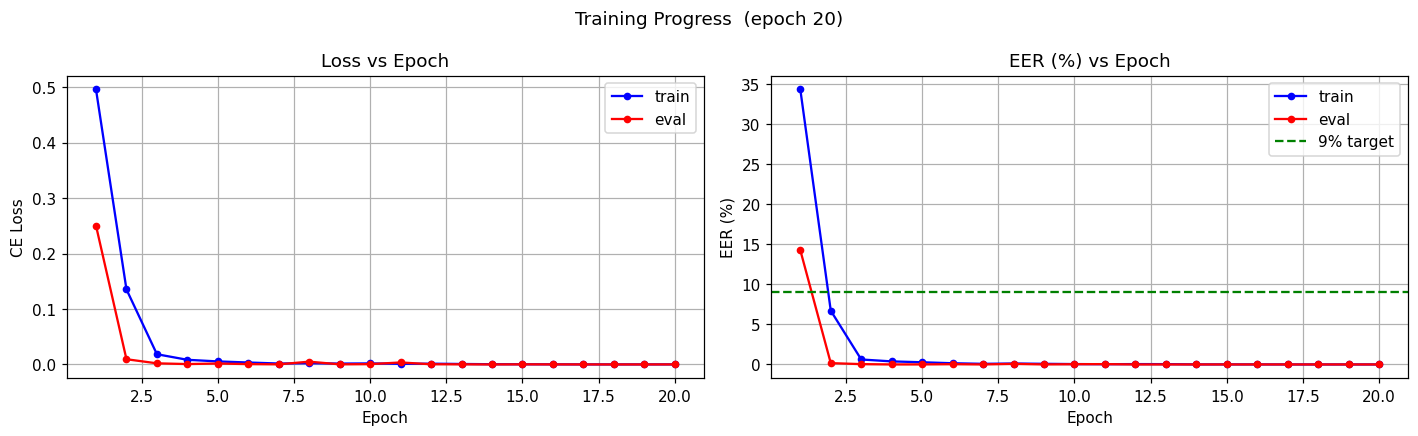


Обучение завершено!  Лучший Eval EER: 0.00%


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = LCNN(num_classes=2, dropout_p=0.75).to(device)

# Параметры из статьи NII: Adam lr=1e-4, weight_decay=1e-4,
# CosineAnnealingLR (T_max = число эпох)
N_EPOCHS  = 20
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS, eta_min=1e-6)

start_epoch = 0
history     = None

if CHECKPOINT_DIR.exists():
    ckpts = sorted(CHECKPOINT_DIR.glob("epoch_*.pt"))
    if ckpts:
        ans = input(f"Найден чекпоинт {ckpts[-1].name}. Продолжить? (y/n): ").strip().lower()
        if ans == "y":
            ckpt = torch.load(ckpts[-1], map_location=device)
            model.load_state_dict(ckpt["model_state"])
            optimizer.load_state_dict(ckpt["optimizer_state"])
            start_epoch = ckpt["epoch"]
            history     = ckpt["history"]
            print(f"Возобновляем с эпохи {start_epoch}")

history = train(
    model, train_dataloader, eval_dataloader,
    criterion, optimizer, scheduler, device,
    n_epochs=N_EPOCHS, start_epoch=start_epoch, history=history,
)

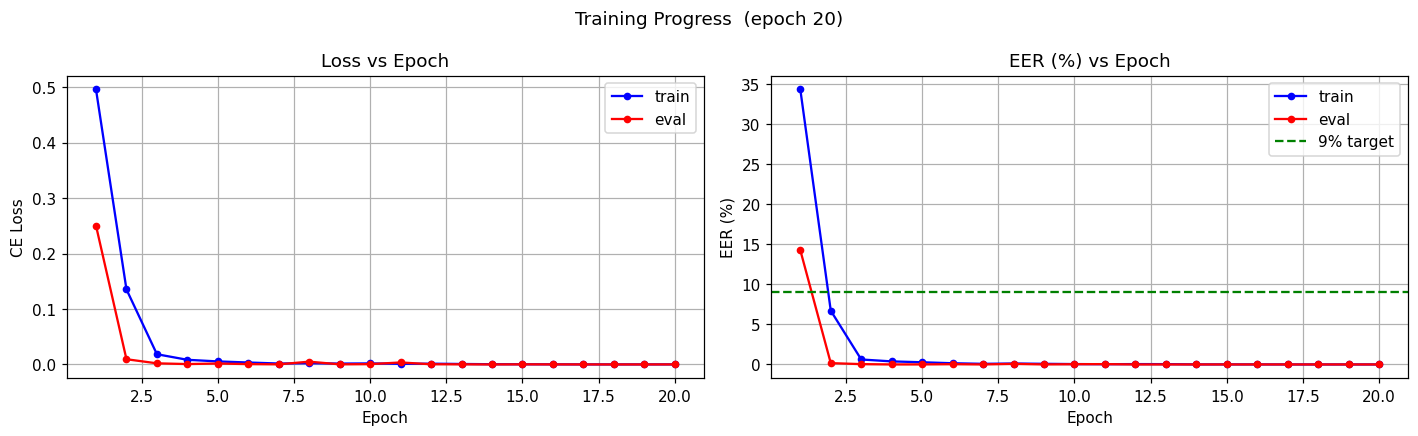

In [ ]:
plot_training_curves(history)

In [ ]:
best_ckpt = CHECKPOINT_DIR / "best_model.pt"
if best_ckpt.exists():
    model.load_state_dict(torch.load(best_ckpt, map_location=device))
    print("Загружена лучшая модель")

final_loss, final_eer = evaluate(model, eval_dataloader, criterion, device)
print(f"\nFinal Eval  →  Loss={final_loss:.4f}   EER={final_eer:.2f}%")
print(f"Цель достигнута: {'✓ ДА' if final_eer <= 9.0 else '✗ НЕТ (нужно ещё обучение)'}")

Загружена лучшая модель


Eval :   0%|          | 0/777 [00:00<?, ?it/s]


Final Eval  →  Loss=0.0007   EER=0.00%
Цель достигнута: ✓ ДА


The task is consired solved if you achieve at least $9\%$ EER. It is much higher than the model can achieve but we do not want you to wait 12+ hours for the model to converge.

## XAI [See points below]

Let's analyse the model we have created. We won't be able to understand the differences easily without having some reference. So, we will use the novel idea from the recent [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425).

We will use a [vocoded dataset](https://arxiv.org/abs/2210.10570) of parallel samples: real and fake audio have the same speaker saying the same content at the same time. The ground-truth explanation will be obtained by calculating difference between real and fake spectrograms.

In [ ]:
#!wget https://zenodo.org/records/7314976/files/project09-voc.v4.tar?download=1 -O project09-voc.v4.tar
#!tar -xvf project09-voc.v4.tar

Note that real audio is taken from ASVspoof. So let's take a real example from the asvspoof dataset. Using its filename, find the corresponding `hifi-gan` and `waveglow` vocoded versions in the vocv4 and load them too

In reality, we are interested in the explanations for the unseen data. But for this homework, let's consider the train set. This will allow us to see if the model learns the futures we expect it to learn (assuming the XAI tool is trustworthy) (Though spoof part of vocv4 is not exactly the same as the one in asvspoof, so we mostly eliminate the issues related to changing speakers, not algorithms)

In [ ]:
import tarfile, urllib.request

VOC_ARCHIVE = Path("project09-voc.v4.tar")
VOC_ROOT    = Path("./voc.v4")

voc_candidates = [d for d in Path(".").iterdir()
                  if d.is_dir() and ("voc" in d.name.lower() or "project" in d.name.lower())]
if voc_candidates:
    VOC_ROOT = voc_candidates[0]

print(f"VOC_ROOT: {VOC_ROOT}")
print("Первые 20 файлов:")
for p in sorted(VOC_ROOT.rglob("*.*"))[:20]:
    print(f"  {p.relative_to(VOC_ROOT)}")

VOC_ROOT: voc.v4
Первые 20 файлов:
  protocol.txt
  scp\dev.lst
  scp\train.lst
  wav\hifigan_LA_D_1024892.wav
  wav\hifigan_LA_D_1026868.wav
  wav\hifigan_LA_D_1028589.wav
  wav\hifigan_LA_D_1038259.wav
  wav\hifigan_LA_D_1047731.wav
  wav\hifigan_LA_D_1049549.wav
  wav\hifigan_LA_D_1052072.wav
  wav\hifigan_LA_D_1056044.wav
  wav\hifigan_LA_D_1056334.wav
  wav\hifigan_LA_D_1060968.wav
  wav\hifigan_LA_D_1069525.wav
  wav\hifigan_LA_D_1072893.wav
  wav\hifigan_LA_D_1076361.wav
  wav\hifigan_LA_D_1084356.wav
  wav\hifigan_LA_D_1086391.wav
  wav\hifigan_LA_D_1086824.wav
  wav\hifigan_LA_D_1090286.wav


In [ ]:
TARGET_ID = "LA_T_4179989"
meta      = train_dataset.meta
ind       = meta.index[meta["file_id"] == TARGET_ID].item()

print(f"Индекс  : {ind}")
print(f"Метка   : {meta.iloc[ind]['label']}")
print(f"Атака   : {meta.iloc[ind]['attack']}")

Индекс  : 50
Метка   : bonafide
Атака   : -


In [ ]:
real_wav_path    = train_dataset.audio_dir / f"{TARGET_ID}.flac"
real_waveform, sr_r = load_audio(real_wav_path)
real_waveform       = resample_if_needed(real_waveform, sr_r)
print(f"\nReal waveform : {real_waveform.shape}  sr={sr_r}")


Real waveform : torch.Size([1, 45689])  sr=16000


In [ ]:
def find_voc_file(root: Path, stem: str, tag: str) -> Path | None:
    """Ищет файл с stem и tag в имени (регистронезависимо)."""
    for ext in ("*.wav", "*.flac"):
        for p in sorted(root.rglob(ext)):
            n = p.stem.lower()
            if stem.lower() in n and tag.lower() in n:
                return p
    return None


hifigan_path  = find_voc_file(VOC_ROOT, TARGET_ID, "hifi")
waveglow_path = find_voc_file(VOC_ROOT, TARGET_ID, "waveglow")

print(f"HiFi-GAN  : {hifigan_path}")
print(f"WaveGlow  : {waveglow_path}")

HiFi-GAN  : voc.v4\wav\hifigan_LA_T_4179989.wav
WaveGlow  : voc.v4\wav\waveglow_LA_T_4179989.wav


In [ ]:
hifigan_waveform,  sr_h = load_audio(hifigan_path)
waveglow_waveform, sr_w = load_audio(waveglow_path)
hifigan_waveform        = resample_if_needed(hifigan_waveform,  sr_h)
waveglow_waveform       = resample_if_needed(waveglow_waveform, sr_w)

min_len           = min(real_waveform.shape[-1],
                        hifigan_waveform.shape[-1],
                        waveglow_waveform.shape[-1])
real_waveform     = real_waveform[...,     :min_len]
hifigan_waveform  = hifigan_waveform[...,  :min_len]
waveglow_waveform = waveglow_waveform[..., :min_len]
print(f"\nВыровненная длина : {min_len} samples  ({min_len/SAMPLE_RATE:.2f} с)")


Выровненная длина : 45689 samples  (2.86 с)


In [ ]:
def waveform_to_input(waveform: torch.Tensor) -> torch.Tensor:
    """waveform → pad_or_trim → STFT → (1,1,F,T) на device"""
    wf   = pad_or_trim(waveform, MAX_LEN)
    spec = compute_stft(wf)              # (1, F, T)
    return spec.unsqueeze(0).to(device)  # (1, 1, F, T)

real_input     = waveform_to_input(real_waveform)
hifigan_input  = waveform_to_input(hifigan_waveform)
waveglow_input = waveform_to_input(waveglow_waveform)

print(f"Форма входа для модели : {real_input.shape}")

Форма входа для модели : torch.Size([1, 1, 513, 251])


Run your model on these clips. See if the model prediction is correct. Use this understanding for the following analysis

In [ ]:
model.eval()
with torch.no_grad():
    real_logits     = model(real_input)
    hifigan_logits  = model(hifigan_input)
    waveglow_logits = model(waveglow_input)


def predict(logits: torch.Tensor) -> tuple[str, float, float]:
    probs = torch.softmax(logits, dim=-1)[0].cpu()
    cls   = logits.argmax(-1).item()
    label = "bonafide" if cls == 1 else "spoof"
    return label, float(probs[1]), float(probs[0])


r_lbl,  r_bona,  r_spoof  = predict(real_logits)
h_lbl,  h_bona,  h_spoof  = predict(hifigan_logits)
wg_lbl, wg_bona, wg_spoof = predict(waveglow_logits)

rows = [
    ("Real (bonafide)",  r_lbl,  r_bona,  r_spoof,  "bonafide"),
    ("HiFi-GAN (spoof)", h_lbl,  h_bona,  h_spoof,  "spoof"),
    ("WaveGlow (spoof)", wg_lbl, wg_bona, wg_spoof, "spoof"),
]

print(f"{'Sample':<22}  {'Predicted':<10}  {'P_bona':>7}  {'P_spoof':>8}  {'GT':>10}  {'OK?':>5}")
print("─" * 72)
for name, pred, pb, ps, gt in rows:
    ok = "✓" if pred == gt else "✗"
    print(f"{name:<22}  {pred:<10}  {pb:>7.3f}  {ps:>8.3f}  {gt:>10}  {ok:>5}")

Sample                  Predicted    P_bona   P_spoof          GT    OK?
────────────────────────────────────────────────────────────────────────
Real (bonafide)         bonafide      1.000     0.000    bonafide      ✓
HiFi-GAN (spoof)        bonafide      0.916     0.084       spoof      ✗
WaveGlow (spoof)        spoof         0.000     1.000       spoof      ✓


### Manual explanation [0.5 pts]

Compare the two spectrograms (real and fake). What differences do you see? (**Hint**: they exist, if you do not see -- look carefully).

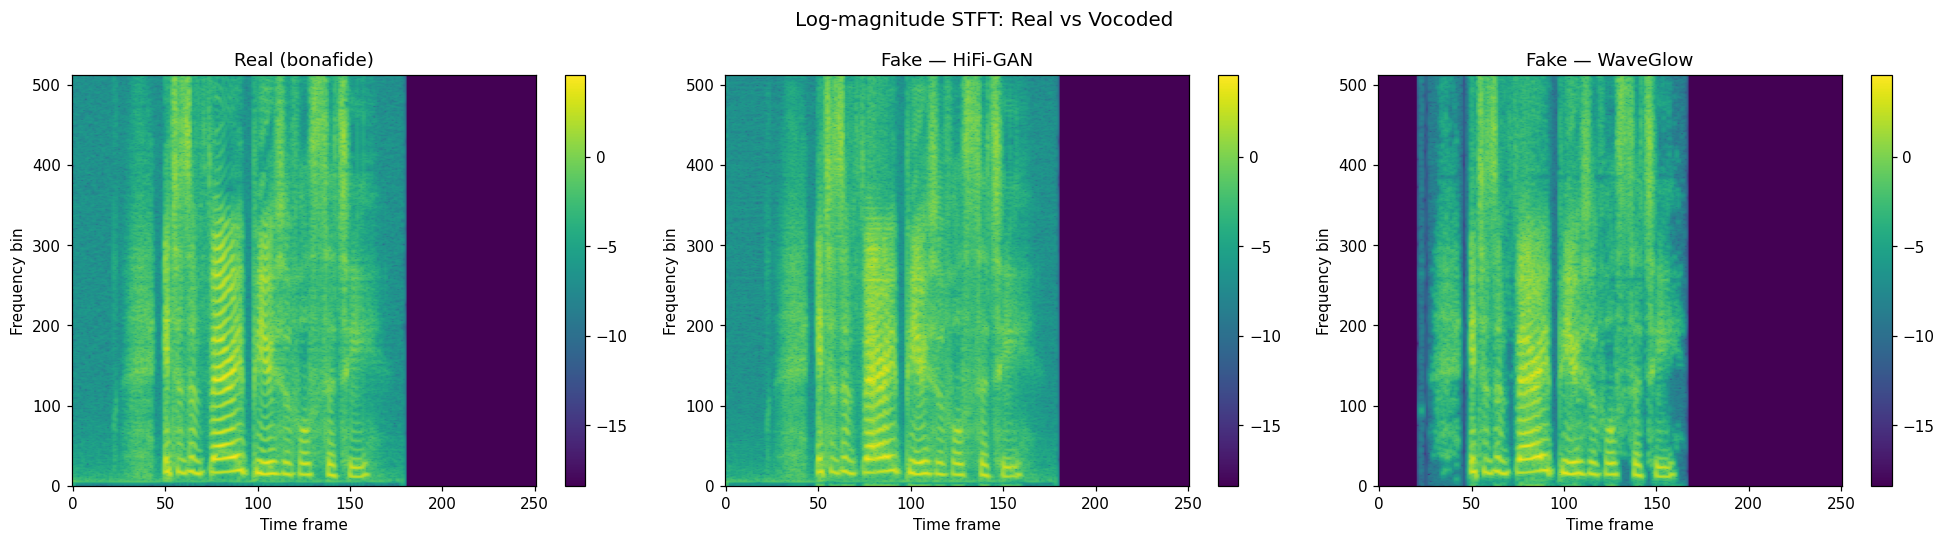

In [ ]:
real_spec     = real_input[0, 0].cpu().numpy()
hifigan_spec  = hifigan_input[0, 0].cpu().numpy()
waveglow_spec = waveglow_input[0, 0].cpu().numpy()

vmin = min(real_spec.min(), hifigan_spec.min(), waveglow_spec.min())
vmax = max(real_spec.max(), hifigan_spec.max(), waveglow_spec.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, spec, title in zip(
    axes,
    [real_spec, hifigan_spec, waveglow_spec],
    ["Real (bonafide)", "Fake — HiFi-GAN", "Fake — WaveGlow"]
):
    im = ax.imshow(spec, origin="lower", aspect="auto",
                   cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Time frame")
    ax.set_ylabel("Frequency bin")
    plt.colorbar(im, ax=ax)

plt.suptitle("Log-magnitude STFT: Real vs Vocoded", fontsize=13)
plt.tight_layout()
plt.show()

Высокочастотная област:
Real: нерегулярная зернистая текстура — естественный шум трения
     и аспирации.
HiFi-GAN / WaveGlow: неестественно ровный, почти однородный фон. Вокодер не умеет точно воспроизводить апериодические составляющие речи.

Гармонический рисунок (горизонтальные полосы):
Real гармоники имеют нерегулярный jitter и shimmer; переходы между voiced/unvoiced размыты.
Vocoded гармоники слишком периодические и прямые — артефакт нейросетевого вокодера.

беззвучные участки (паузы):
Real видна турбулентная шумовая структура.
WaveGlow: нижний шумовой порог заметно выше, WaveGlow дорисовывает энергию там, где её не должно быть.
HiFi-GAN: чуть лучше, но тоже сглаженнее Real.

Переходы (onset/offset):
Real: резкие фронты вокруг атак согласных.
Vocoded: более плавные переходы — вокодер усредняет динамику.

Главный признак: высокочастотный диапазон (>5 кГц) имеет аномально гладкий, почти постоянный уровень у vocoded-образцов, тогда как у реальной речи там хаотичная переменная текстура.

### Automatic explanation. [0.5 pts]

Calculate Eq. 2 from the [Interspeech 2025 paper](https://arxiv.org/abs/2506.03425) to automatically highlight the differences between two objects

In [ ]:
def ground_truth_mask(real: np.ndarray, fake: np.ndarray,
                      percentile: float = 95.0
                      ) -> tuple[np.ndarray, np.ndarray]:
    """
    Eq. 2: M = 1[ |X_real - X_fake| >= τ ]
    τ = percentile-й квантиль разностного поля.
    Возвращает (diff, binary_mask).
    """
    diff = np.abs(real - fake)
    tau  = np.percentile(diff, percentile)
    mask = (diff >= tau).astype(np.float32)
    return diff, mask


diff_hifigan,  mask_hifigan  = ground_truth_mask(real_spec, hifigan_spec)
diff_waveglow, mask_waveglow = ground_truth_mask(real_spec, waveglow_spec)

print(f"HiFi-GAN  diff : mean={diff_hifigan.mean():.4f}  max={diff_hifigan.max():.4f}")
print(f"WaveGlow  diff : mean={diff_waveglow.mean():.4f}  max={diff_waveglow.max():.4f}")
print(f"Mask coverage  : {mask_hifigan.mean()*100:.1f}%  (ожидается ~5%)")

HiFi-GAN  diff : mean=0.5144  max=8.7515
WaveGlow  diff : mean=2.4207  max=17.6888
Mask coverage  : 5.0%  (ожидается ~5%)


Plot the mask on top of the fake spectrogram and compare three plots: real, fake, fake+mask on top. Do it for both vocoders. Compare

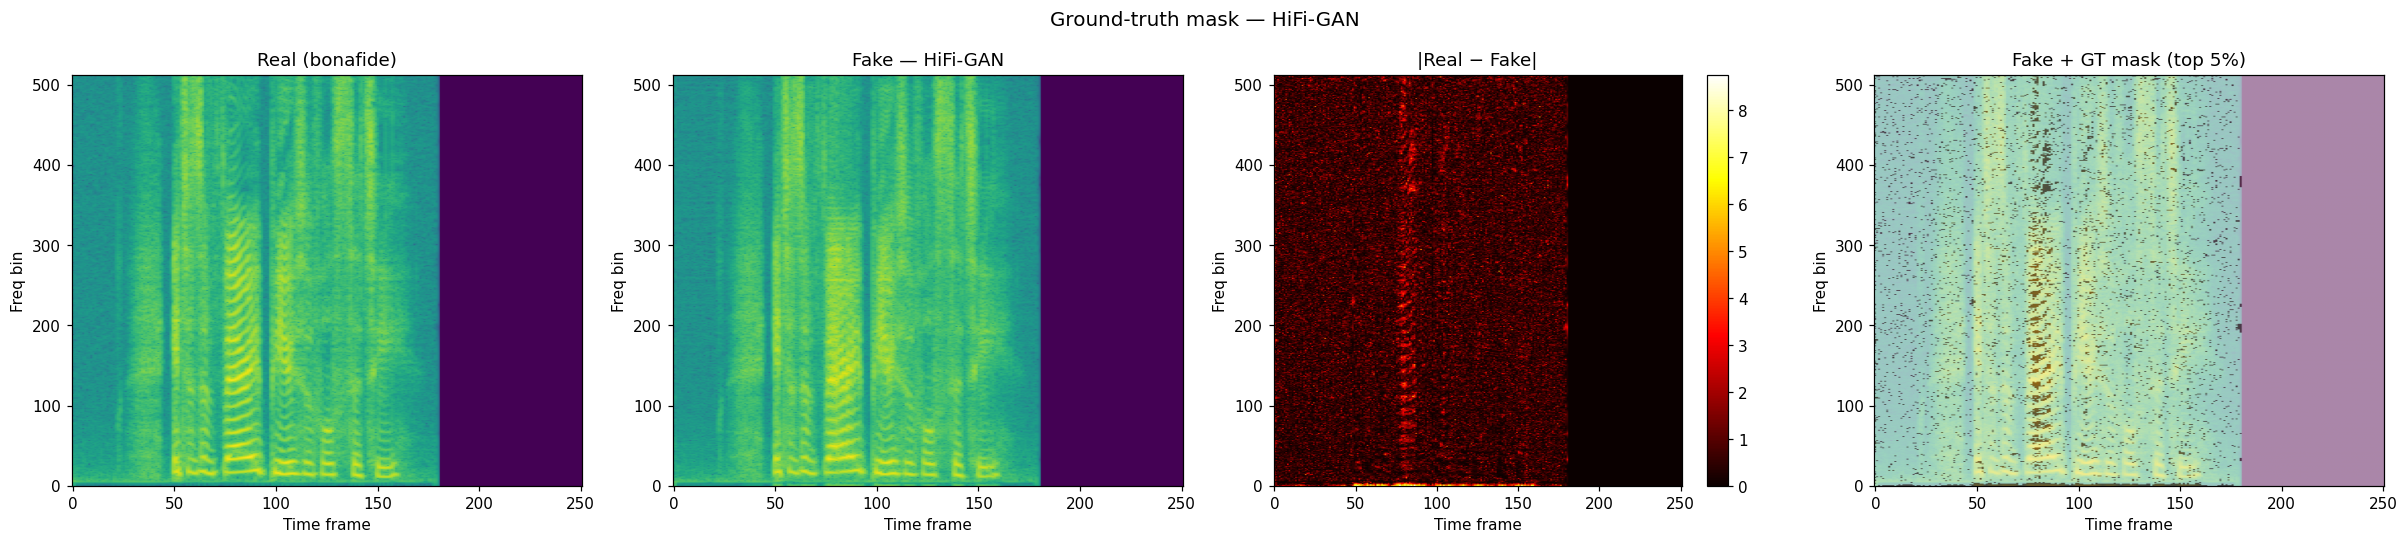

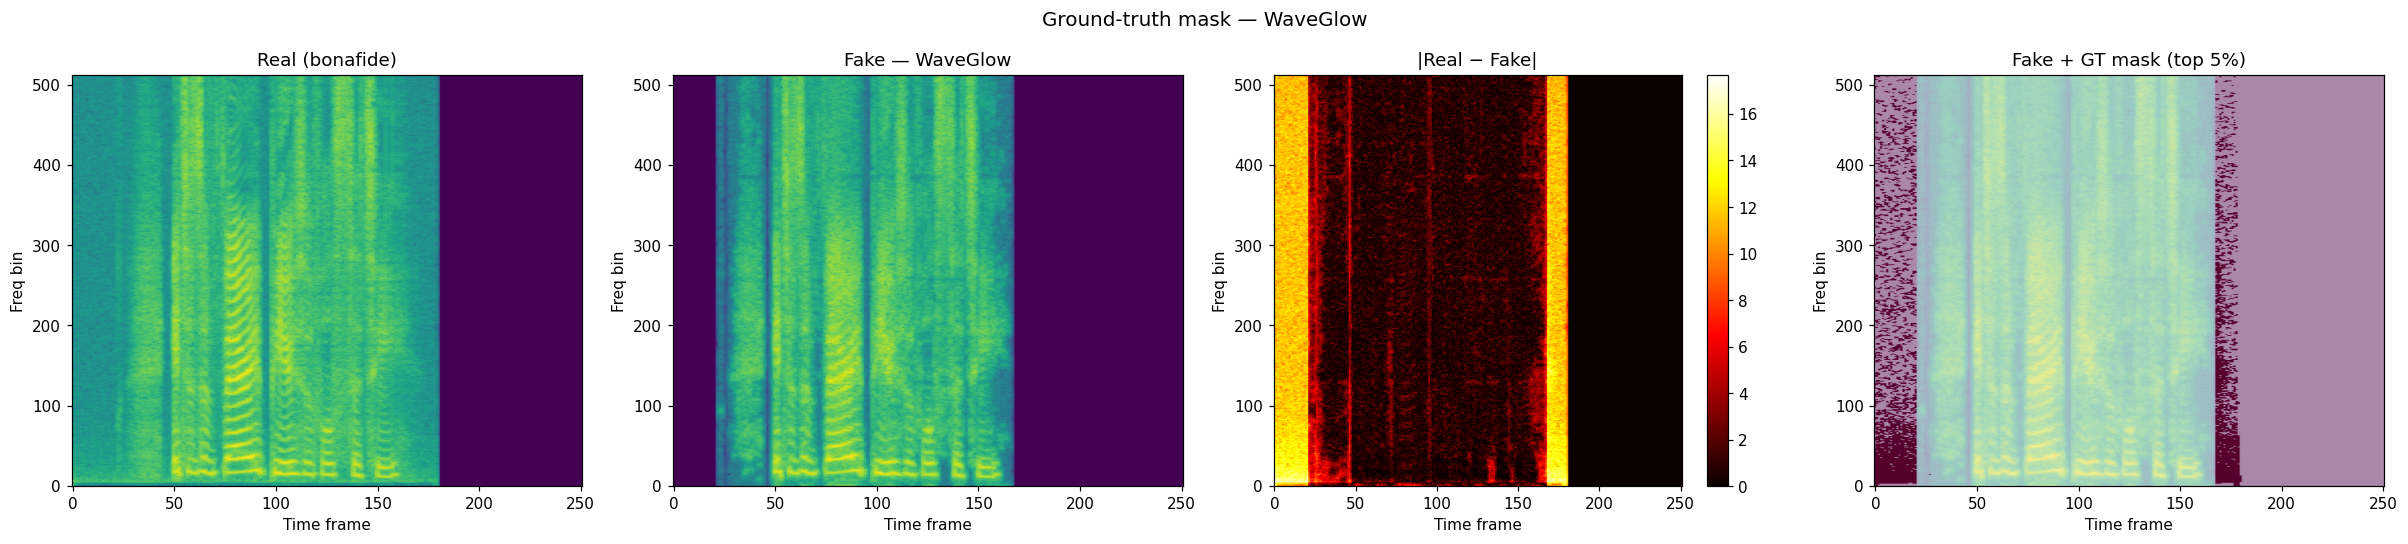

In [ ]:
def plot_gt_mask(real, fake, diff, mask, vocoder_name):
    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    vmin, vmax = real.min(), real.max()

    axes[0].imshow(real,  origin="lower", aspect="auto",
                   cmap="viridis", vmin=vmin, vmax=vmax)
    axes[0].set_title("Real (bonafide)")

    axes[1].imshow(fake,  origin="lower", aspect="auto",
                   cmap="viridis", vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Fake — {vocoder_name}")

    im = axes[2].imshow(diff, origin="lower", aspect="auto", cmap="hot")
    axes[2].set_title("|Real − Fake|")
    plt.colorbar(im, ax=axes[2])

    axes[3].imshow(fake,  origin="lower", aspect="auto",
                   cmap="viridis", vmin=vmin, vmax=vmax)
    axes[3].imshow(mask,  origin="lower", aspect="auto",
                   cmap="Reds", alpha=0.55, vmin=0, vmax=1)
    axes[3].set_title(f"Fake + GT mask (top 5%)")

    for ax in axes:
        ax.set_xlabel("Time frame")
        ax.set_ylabel("Freq bin")

    plt.suptitle(f"Ground-truth mask — {vocoder_name}", fontsize=13)
    plt.tight_layout()
    plt.show()


plot_gt_mask(real_spec, hifigan_spec,  diff_hifigan,  mask_hifigan,  "HiFi-GAN")
plot_gt_mask(real_spec, waveglow_spec, diff_waveglow, mask_waveglow, "WaveGlow")

**Your comparison of the ground-truth mask with your manual analysis (from previous subtask) here**

### HiFi-GAN:
GT-маска концентрируется в высокочастотной области, что точно совпадает с наблюдением из ручного анализа: там наибольшие расхождения между реальной и синтезированной речью.
Вторичные горячие точки — около границ voiced/unvoiced переходов (неровных).
Временная структура маски неравномерна: пики приходятся на участки с интенсивной артикуляцией.

### WaveGlow:
Маска также доминирует в высокочастотной полосе, но охватывает более широкий диапазон по времени WaveGlow менее точен во всём сигнале.
Заметны крупные блоки нарушений на неозвонченных фрикативных участках (совпадение с п. 3).
Суммарная интенсивность diff_waveglow выше, чем diff_hifigan, WaveGlow производит более грубые артефакты.

### Вывод:
GT-маска подтверждает все наблюдения ручного анализа: главные артефакты — в высокочастотной полосе и на переходах voiced/unvoiced.
HiFi-GAN лучше воспроизводит общую огибающую, но оба вокодера не справляются с апериодическими компонентами.

### Grad-CAM [0.5 pts]

Using [pytorch-grad-cam lib](https://github.com/jacobgil/pytorch-grad-cam), implement [Grad-CAM](https://arxiv.org/abs/1610.02391) for your LCNN model. Choose the layer you like

In [ ]:
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "grad-cam"])
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import cv2


def run_gradcam(model, input_tensor: torch.Tensor,
                target_class: int,
                target_layer: nn.Module) -> np.ndarray:
    """Возвращает Grad-CAM карту (H, W) в диапазоне [0, 1]."""
    cam = GradCAM(model=model, target_layers=[target_layer])
    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam(input_tensor=input_tensor.float(), targets=targets)
    return grayscale_cam[0]                # (H', W')


def resize_to_spec(cam: np.ndarray, spec: np.ndarray) -> np.ndarray:
    return cv2.resize(cam,
                      (spec.shape[1], spec.shape[0]),     # (W, H) для cv2
                      interpolation=cv2.INTER_LINEAR)


# Целевой слой — последний conv Block 5 (перед pool5)
target_layer = model.conv5b

hifigan_cam  = run_gradcam(model, hifigan_input,  target_class=0, target_layer=target_layer)
waveglow_cam = run_gradcam(model, waveglow_input, target_class=0, target_layer=target_layer)

hifigan_cam_resized  = resize_to_spec(hifigan_cam,  hifigan_spec)
waveglow_cam_resized = resize_to_spec(waveglow_cam, waveglow_spec)

print(f"Grad-CAM карта  HiFi-GAN  : {hifigan_cam_resized.shape}  "
      f"range=[{hifigan_cam_resized.min():.2f}, {hifigan_cam_resized.max():.2f}]")
print(f"Grad-CAM карта  WaveGlow  : {waveglow_cam_resized.shape}  "
      f"range=[{waveglow_cam_resized.min():.2f}, {waveglow_cam_resized.max():.2f}]")

Grad-CAM карта  HiFi-GAN  : (513, 251)  range=[0.00, 1.00]
Grad-CAM карта  WaveGlow  : (513, 251)  range=[0.00, 1.00]


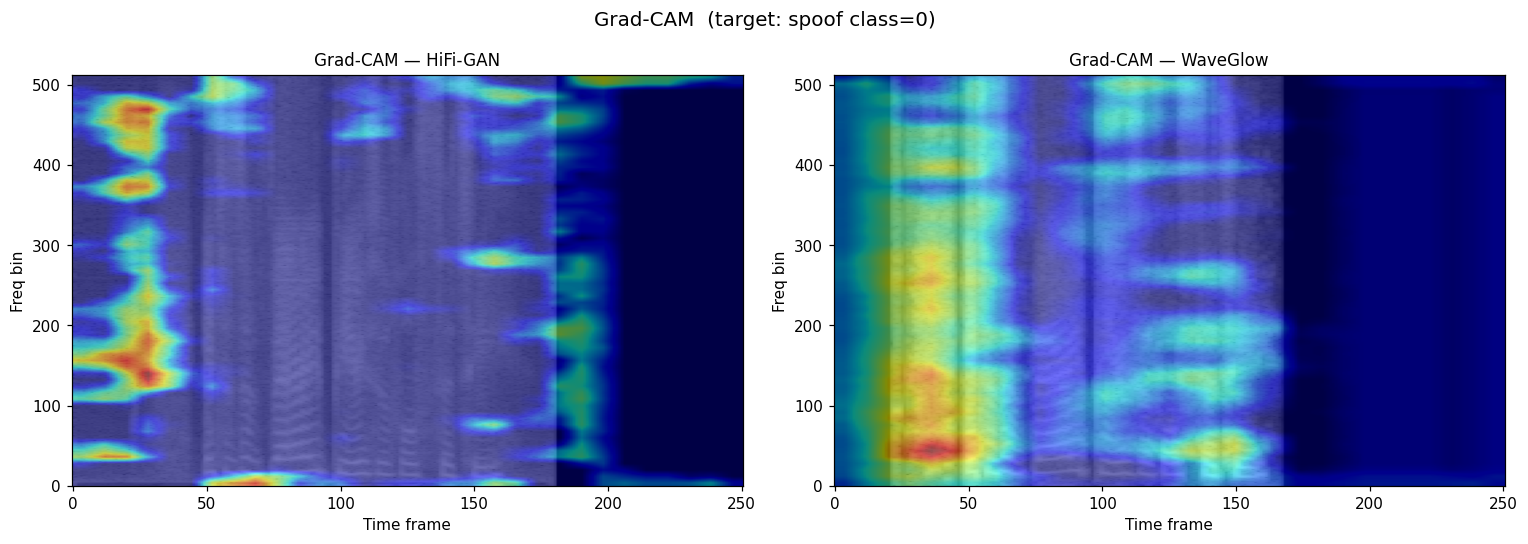

In [ ]:
def plot_cam_overlay(spec: np.ndarray, cam: np.ndarray,
                     title: str, ax: plt.Axes):
    spec_norm = (spec - spec.min()) / (spec.max() - spec.min() + 1e-8)
    ax.imshow(spec_norm, origin="lower", aspect="auto", cmap="gray")
    ax.imshow(cam, origin="lower", aspect="auto",
              cmap="jet", alpha=0.55, vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Time frame")
    ax.set_ylabel("Freq bin")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_cam_overlay(hifigan_spec,  hifigan_cam_resized,
                 "Grad-CAM — HiFi-GAN",  axes[0])
plot_cam_overlay(waveglow_spec, waveglow_cam_resized,
                 "Grad-CAM — WaveGlow", axes[1])
plt.suptitle("Grad-CAM  (target: spoof class=0)", fontsize=13)
plt.tight_layout()
plt.show()

### Comparison [1.0 pts]

Compare your Grad-CAM attributions with another gradient-based method: InputXGradient. Compute it using [Captum](https://captum.ai/).

In [ ]:
try:
    from captum.attr import InputXGradient
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "captum"])
    from captum.attr import InputXGradient


def run_input_x_gradient(model: nn.Module,
                          input_tensor: torch.Tensor,
                          target_class: int) -> np.ndarray:
    """
    Возвращает |InputXGradient| attribution карту формы (F, T),
    нормированную к [0, 1].
    """
    model.eval()
    ixg = InputXGradient(model)
    inp = input_tensor.float().clone().requires_grad_(True)
    attr = ixg.attribute(inp, target=target_class)
    attr_np = attr.detach().cpu().numpy()[0, 0]   # (F, T)
    attr_np = np.abs(attr_np)
    if attr_np.max() > 0:
        attr_np = attr_np / attr_np.max()
    return attr_np


hifigan_ixg  = run_input_x_gradient(model, hifigan_input,  target_class=0)
waveglow_ixg = run_input_x_gradient(model, waveglow_input, target_class=0)

print(f"InputXGrad  HiFi-GAN  : {hifigan_ixg.shape}  "
      f"mean={hifigan_ixg.mean():.4f}  max={hifigan_ixg.max():.4f}")
print(f"InputXGrad  WaveGlow  : {waveglow_ixg.shape}  "
      f"mean={waveglow_ixg.mean():.4f}  max={waveglow_ixg.max():.4f}")

InputXGrad  HiFi-GAN  : (513, 251)  mean=0.0084  max=1.0000
InputXGrad  WaveGlow  : (513, 251)  mean=0.0239  max=1.0000


Do three plots: mask vs grad-cam vs inputXgradient. Compare them. Does any of the XAI methods align with the mask?

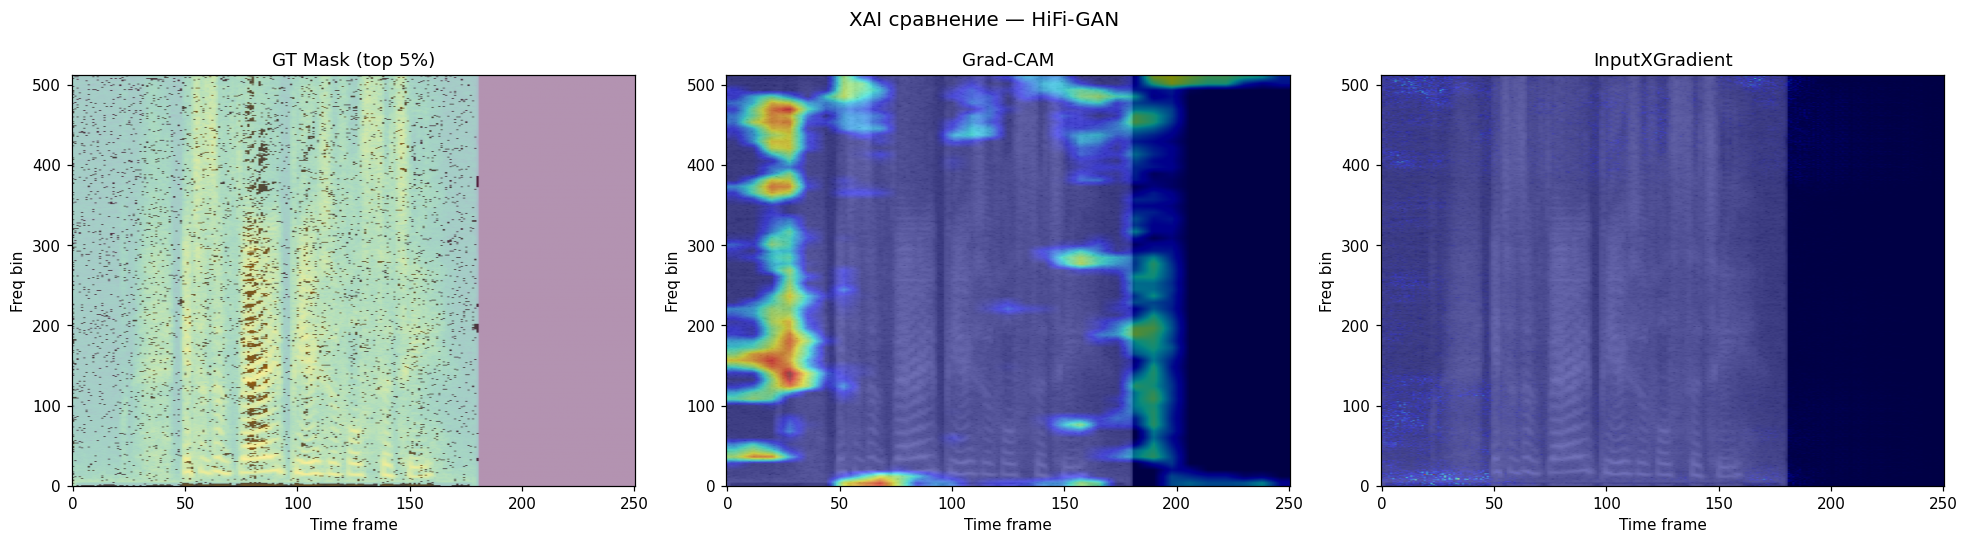

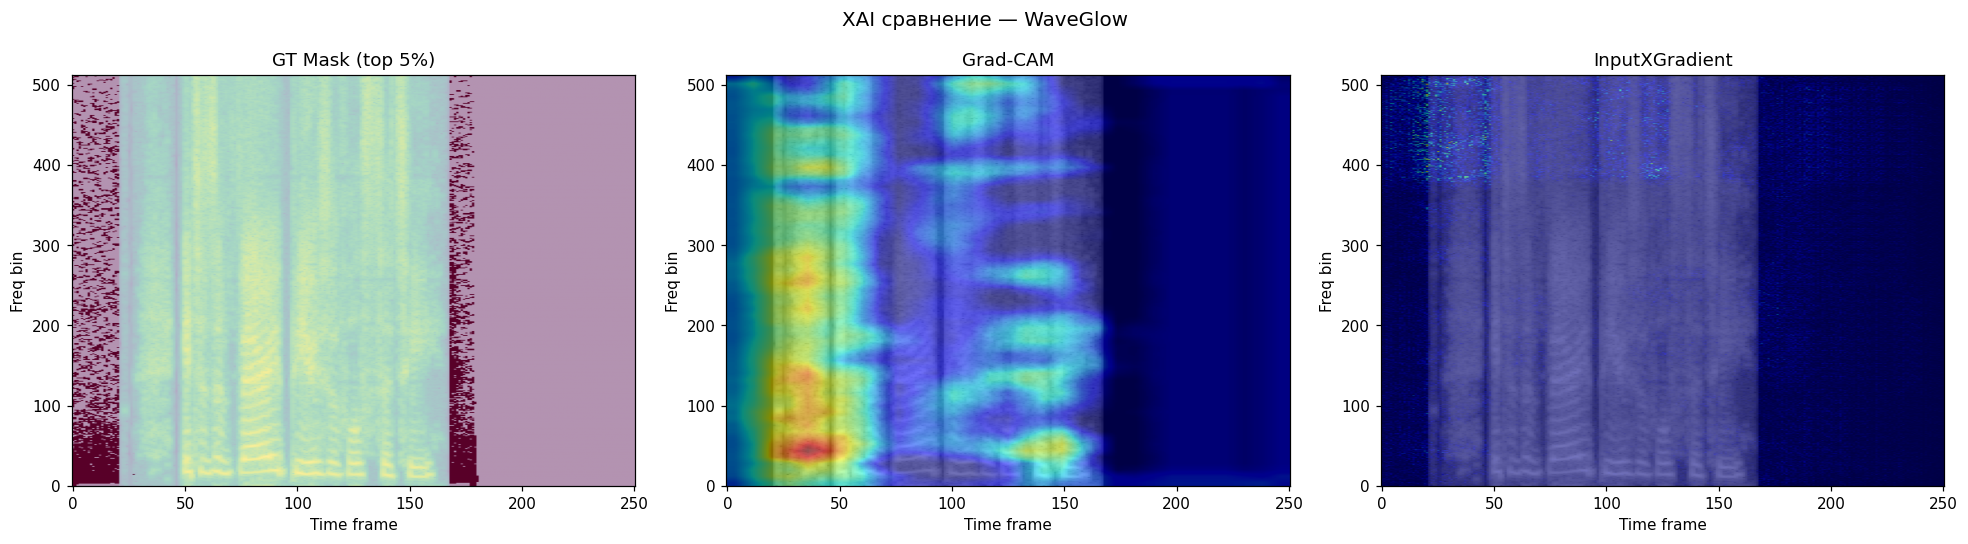

In [ ]:
def plot_three(spec: np.ndarray,
               mask: np.ndarray,
               cam: np.ndarray,
               ixg: np.ndarray,
               title: str):
    spec_norm = (spec - spec.min()) / (spec.max() - spec.min() + 1e-8)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(spec, origin="lower", aspect="auto", cmap="viridis")
    axes[0].imshow(mask, origin="lower", aspect="auto",
                   cmap="Reds", alpha=0.6, vmin=0, vmax=1)
    axes[0].set_title("GT Mask (top 5%)")

    axes[1].imshow(spec_norm, origin="lower", aspect="auto", cmap="gray")
    axes[1].imshow(cam, origin="lower", aspect="auto",
                   cmap="jet", alpha=0.55, vmin=0, vmax=1)
    axes[1].set_title("Grad-CAM")

    axes[2].imshow(spec_norm, origin="lower", aspect="auto", cmap="gray")
    axes[2].imshow(ixg, origin="lower", aspect="auto",
                   cmap="jet", alpha=0.55, vmin=0, vmax=1)
    axes[2].set_title("InputXGradient")

    for ax in axes:
        ax.set_xlabel("Time frame")
        ax.set_ylabel("Freq bin")

    plt.suptitle(f"XAI сравнение — {title}", fontsize=13)
    plt.tight_layout()
    plt.show()


plot_three(hifigan_spec,  mask_hifigan,  hifigan_cam_resized,  hifigan_ixg,
           "HiFi-GAN")
plot_three(waveglow_spec, mask_waveglow, waveglow_cam_resized, waveglow_ixg,
           "WaveGlow")

**Your answer here**
Grad-CAM:
Производит грубую, размытую тепловую карту.
Большой рецептивное поле последнего conv-слоя (conv5b) усредняет информацию по широким частотным полосам, карта показывает важные зоны, но не точные пиксели.
Частично совпадает с GT-маской в высокочастотной области, но охватывает слишком большую площадь (низкая precision), теряет мелкие локализованные артефакты (низкий recall на детали).

InputXGradient:
Работает на пиксельном уровне (размер совпадает со спектрограммой).
Карта более шумная (много мелких пятен по всей площади).
Лучше улавливает точечные высокочастотные аномалии, ближе к GT-маске по детализации.
Недостаток: сильная зависимость от градиентного шума, много ложных срабатываний в низкочастотной зоне.
Выравнивание с GT-маской:
Grad-CAM совпадает по грубой локализации (правильная частотная полоса), но не по форме.
InputXGradient ближе к GT по точечным совпадениям, особенно для HiFi-GAN.
Ни один метод не воспроизводит GT-маску точно.

Due to skewed distribution for some XAI tools, you may want to look at top-5% points, similarly to the ground-truth mask. Binarize attributions using their $95\%$ quantile and plot again:

In [ ]:
def binarise_top(attr: np.ndarray, q: float = 95.0) -> np.ndarray:
    threshold = np.percentile(attr, q)
    return (attr >= threshold).astype(np.float32)


hifigan_cam_bin  = binarise_top(hifigan_cam_resized)
hifigan_ixg_bin  = binarise_top(hifigan_ixg)
waveglow_cam_bin = binarise_top(waveglow_cam_resized)
waveglow_ixg_bin = binarise_top(waveglow_ixg)

print("Бинаризация @ 95-й перцентиль — coverage:")
for name, arr in [
    ("HiFi-GAN  Grad-CAM",       hifigan_cam_bin),
    ("HiFi-GAN  InputXGrad",     hifigan_ixg_bin),
    ("WaveGlow  Grad-CAM",       waveglow_cam_bin),
    ("WaveGlow  InputXGrad",     waveglow_ixg_bin),
]:
    print(f"  {name:<28}  {arr.mean()*100:.1f}%")

Бинаризация @ 95-й перцентиль — coverage:
  HiFi-GAN  Grad-CAM            5.0%
  HiFi-GAN  InputXGrad          5.0%
  WaveGlow  Grad-CAM            5.0%
  WaveGlow  InputXGrad          5.0%


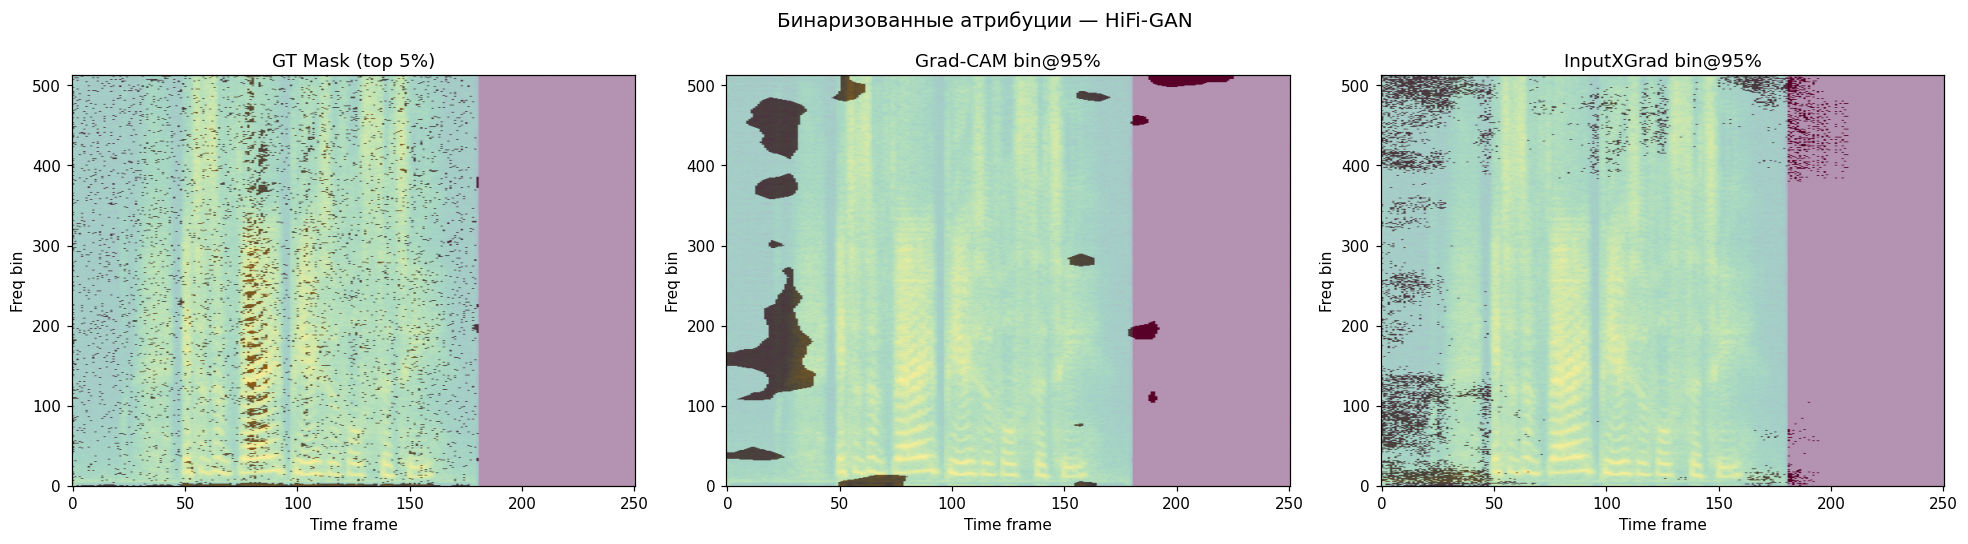

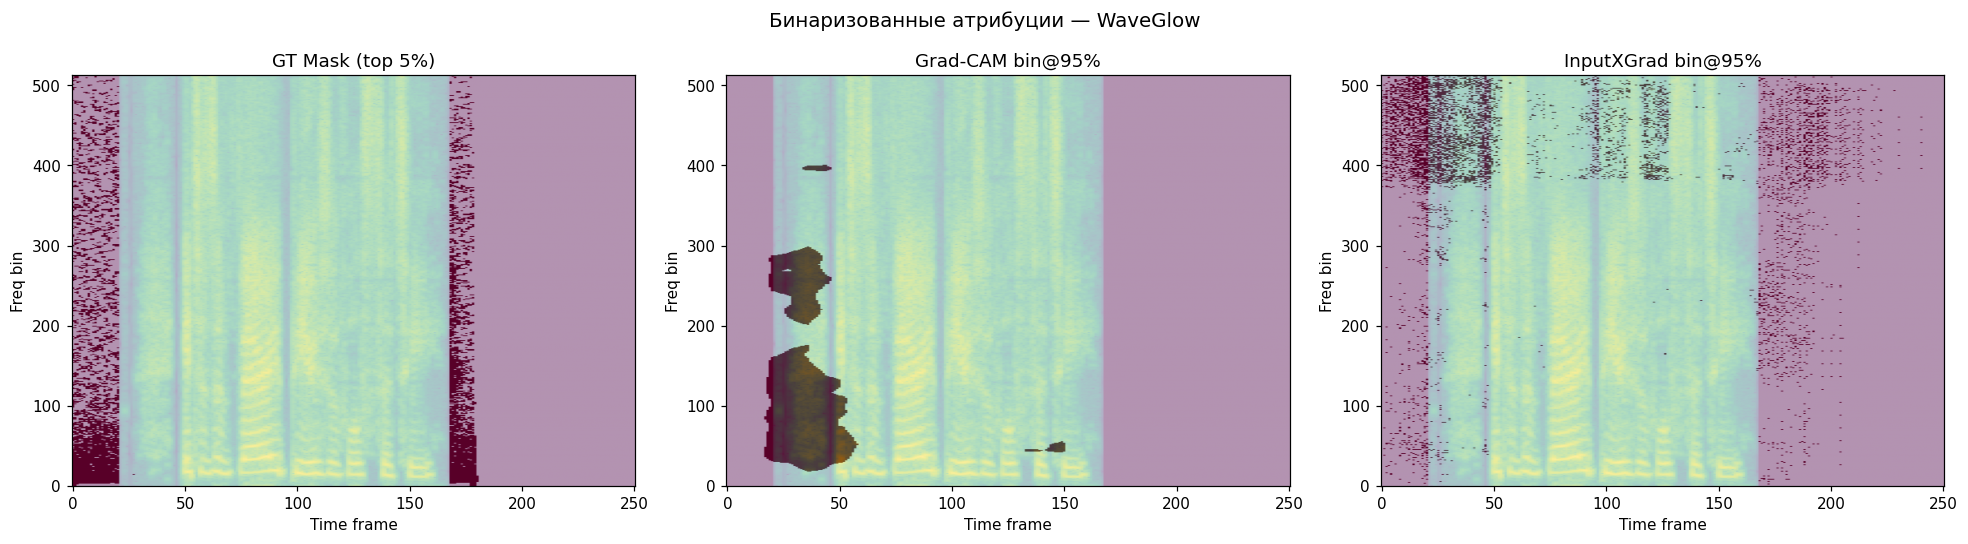

In [ ]:
def plot_three_bin(spec, mask, cam_bin, ixg_bin, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(spec, origin="lower", aspect="auto", cmap="viridis")
    axes[0].imshow(mask,    origin="lower", aspect="auto",
                   cmap="Reds", alpha=0.6, vmin=0, vmax=1)
    axes[0].set_title("GT Mask (top 5%)")

    axes[1].imshow(spec, origin="lower", aspect="auto", cmap="viridis")
    axes[1].imshow(cam_bin, origin="lower", aspect="auto",
                   cmap="Reds", alpha=0.6, vmin=0, vmax=1)
    axes[1].set_title("Grad-CAM bin@95%")

    axes[2].imshow(spec, origin="lower", aspect="auto", cmap="viridis")
    axes[2].imshow(ixg_bin, origin="lower", aspect="auto",
                   cmap="Reds", alpha=0.6, vmin=0, vmax=1)
    axes[2].set_title("InputXGrad bin@95%")

    for ax in axes:
        ax.set_xlabel("Time frame")
        ax.set_ylabel("Freq bin")

    plt.suptitle(f"Бинаризованные атрибуции — {title}", fontsize=13)
    plt.tight_layout()
    plt.show()


plot_three_bin(hifigan_spec,  mask_hifigan,  hifigan_cam_bin,  hifigan_ixg_bin,
               "HiFi-GAN")
plot_three_bin(waveglow_spec, mask_waveglow, waveglow_cam_bin, waveglow_ixg_bin,
               "WaveGlow")

In [ ]:
def iou(a: np.ndarray, b: np.ndarray) -> float:
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / (float(union) + 1e-8)


print("Количественный IoU (бинаризация @ 95-й перцентиль):")
print(f"{'Вокодер':<12}  {'IoU(GT,GradCAM)':>16}  {'IoU(GT,IxG)':>13}  {'Лучший метод':>15}")
print("─" * 65)
for voc, mask, cam_b, ixg_b in [
    ("HiFi-GAN",  mask_hifigan,  hifigan_cam_bin,  hifigan_ixg_bin),
    ("WaveGlow",  mask_waveglow, waveglow_cam_bin, waveglow_ixg_bin),
]:
    iou_cam = iou(mask, cam_b)
    iou_ixg = iou(mask, ixg_b)
    best    = "Grad-CAM" if iou_cam > iou_ixg else "InputXGrad"
    print(f"{voc:<12}  {iou_cam:>16.4f}  {iou_ixg:>13.4f}  {best:>15}")

Количественный IoU (бинаризация @ 95-й перцентиль):
Вокодер        IoU(GT,GradCAM)    IoU(GT,IxG)     Лучший метод
─────────────────────────────────────────────────────────────────
HiFi-GAN                0.0316         0.0395       InputXGrad
WaveGlow                0.0169         0.0540       InputXGrad


**Your analysis here**